# Transfer-Matrix Seat Simulator

Projects 2026 Hungarian parliamentary seats from 2022 district-level results
using a probabilistic voter-transfer model calibrated to the current polling nowcast.

**Approach:**
1. Collapse 2022 OEVK votes into 5 *source blocs* per district
2. Define a national transfer matrix (source → 2026 target) with Dirichlet priors
3. Calibrate it so national aggregates match `nowcast_latest.json`
4. Add district-level logistic-normal deviations
5. Monte Carlo: sample district votes → OEVK winners → győzteskompenzáció → d'Hondt list seats

All core logic lives in `lib/`. This notebook is an interactive explorer.

In [1]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import softmax
from IPython.display import Image, display

from seats import load_2022_baseline, seat_calculator, FIDESZ, EEGY
from lib.config import SimConfig
from lib.transfer_model import (
    Q_PRIOR, SOURCES, TARGETS, S, T,
    load_baseline_and_matrix, load_nowcast,
    calibrate_transfer_matrix, check_calibration,
    run_simulation, aggregate_results,
    transfer_matrix_report, prior_vs_calibrated,
)
from lib.reports import (
    print_seat_summary, print_outcome_probabilities,
    plot_seat_distributions, plot_seat_scatter, plot_transfer_matrix,
)

plt.rcParams.update({
    'figure.figsize': (14, 7),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 12,
})

cfg = SimConfig(n_sim=5000)
print(f"Config: n_sim={cfg.n_sim}, sigma={cfg.sigma_district}, conc={cfg.conc_national}, lam={cfg.lam_prior}")

Config: n_sim=5000, sigma=0.15, conc=80.0, lam=5.0


## 1. Load data

In [2]:
baseline = load_2022_baseline()
V22, districts = load_baseline_and_matrix()
nowcast_shares, nowcast_se, raw_nowcast_shares = load_nowcast(cfg.nowcast_json)

print(f"Districts: {len(districts)}")
print(f"Source blocs: {SOURCES}")
print(f"Target blocs: {TARGETS}")
print(f"\nNational 2022 source totals:")
for j, src in enumerate(SOURCES):
    print(f"  {src:<12s} {V22[:, j].sum():>12,.0f}  ({V22[:, j].sum() / V22.sum() * 100:.1f}%)")
print(f"  {'TOTAL':<12s} {V22.sum():>12,.0f}")
print(f"\nNowcast targets:")
for t_name, s in nowcast_shares.items():
    se = nowcast_se.get(t_name, 0)
    print(f"  {t_name:<12s} {s*100:>6.1f}%  (+-{se*100:.1f}pp)")

  Nowcast: raw sum 0.9999 -> renormalized to 1.0 (decided shares)
Districts: 106
Source blocs: ['Fidesz22', 'Opp22', 'MH22', 'MKKP22', 'Other22']
Target blocs: ['Fidesz26', 'TISZA26', 'Bal26', 'MH26', 'MKKP26', 'Other26']

National 2022 source totals:
  Fidesz22        2,823,419  (52.5%)
  Opp22           1,983,708  (36.9%)
  MH22              307,064  (5.7%)
  MKKP22            126,648  (2.4%)
  Other22           134,849  (2.5%)
  TOTAL           5,375,688

Nowcast targets:
  Fidesz26       39.6%  (+-2.6pp)
  TISZA26        47.3%  (+-2.6pp)
  Bal26           3.5%  (+-2.6pp)
  MH26            6.1%  (+-2.6pp)
  MKKP26          3.3%  (+-2.6pp)
  Other26         0.2%  (+-1.4pp)


## 2. Prior transfer matrix

In [3]:
transfer_matrix_report(Q_PRIOR, "Prior transfer matrix Q[source, target]")

V26_prior = V22 @ Q_PRIOR
national_prior = V26_prior.sum(axis=0)
total_prior = national_prior.sum()
print(f"\nImplied national shares (prior, before calibration):")
for j, t_name in enumerate(TARGETS):
    print(f"  {t_name:<12s} {national_prior[j] / total_prior * 100:>6.1f}%   (nowcast: {nowcast_shares.get(t_name, 0)*100:>5.1f}%)")


Prior transfer matrix Q[source, target]:
                 Fidesz26   TISZA26     Bal26      MH26    MKKP26   Other26      SUM
      Fidesz22      89.1%      4.3%      1.1%      3.3%      1.1%      1.1%  100.0%
         Opp22       3.8%     77.5%     10.0%      2.5%      3.8%      2.5%  100.0%
          MH22      15.0%     10.0%      2.5%     65.0%      5.0%      2.5%  100.0%
        MKKP22      10.7%     37.3%      5.3%      5.3%     37.3%      4.0%  100.0%
       Other22      23.1%     30.8%      7.7%     12.3%      7.7%     18.5%  100.0%

Implied national shares (prior, before calibration):
  Fidesz26       49.9%   (nowcast:  39.6%)
  TISZA26        33.1%   (nowcast:  47.3%)
  Bal26           4.7%   (nowcast:   3.5%)
  MH26            6.8%   (nowcast:   6.1%)
  MKKP26          3.3%   (nowcast:   3.3%)
  Other26         2.2%   (nowcast:   0.2%)


## 3. Calibrate transfer matrix

In [4]:
Q_cal = calibrate_transfer_matrix(V22, nowcast_shares, nowcast_se, Q_PRIOR, cfg.lam_prior)

transfer_matrix_report(Q_cal, "Calibrated transfer matrix")
check_calibration(V22, Q_cal, nowcast_shares, raw_nowcast_shares)
prior_vs_calibrated(Q_PRIOR, Q_cal)


Calibrated transfer matrix:
                 Fidesz26   TISZA26     Bal26      MH26    MKKP26   Other26      SUM
      Fidesz22      70.7%     24.2%      1.0%      2.6%      1.4%      0.1%  100.0%
         Opp22       2.3%     86.4%      6.6%      1.5%      2.9%      0.4%  100.0%
          MH22      14.9%     11.2%      2.5%     64.6%      5.2%      1.5%  100.0%
        MKKP22      10.5%     38.5%      5.3%      5.2%     37.5%      3.1%  100.0%
       Other22      23.6%     33.3%      8.0%     12.6%      8.1%     14.4%  100.0%
Calibration fit (model vs nowcast, raw vs renormalized):
  Target         Model  Nowcast     Raw   Error
  ----------------------------------------------------
  Fidesz26       39.6%    39.6%    39.6%   +0.00pp
  TISZA26        46.9%    47.3%    47.3%   -0.35pp
  Bal26           3.4%     3.5%     3.5%   -0.06pp
  MH26            6.0%     6.1%     6.0%   -0.00pp
  MKKP26          3.2%     3.3%     3.3%   -0.15pp
  Other26         0.7%     0.2%     0.2%   +0.57pp


## 4. Monte Carlo simulation

In [5]:
sim_results = run_simulation(V22, Q_cal, districts, cfg, verbose=True)
agg = aggregate_results(sim_results)

print_seat_summary(agg)
print_outcome_probabilities(agg)

Simulating:   0%|          | 0/5000 [00:00<?, ?it/s]

  SEAT PROJECTION  (5,000 simulations)
  Party             OEVK med  List med  Total med    5th%   95th%   P(>0)
  ------------------------------------------------------------------------
  Fidesz-KDNP            34        42         76      48     102     100%
  TISZA                  72        43        115      89     143     100%
  Baloldal                0         0          0       0       6      11%
  Mi Hazank               0         7          7       0      10      84%
  MKKP                    0         0          0       0       6       6%
  Other/EM                0         0          0       0       0       0%
  ------------------------------------------------------------------------
  Draw total (med)                           199     199     199    (should be ~199)
  OUTCOME PROBABILITIES
  TISZA largest party:             87.1%
  TISZA majority (>=100 seats):    80.8%
  Fidesz largest party:            12.0%
  Fidesz majority (>=100 seats):    7.2%
  Fidesz supermajori

## 5. Visualizations

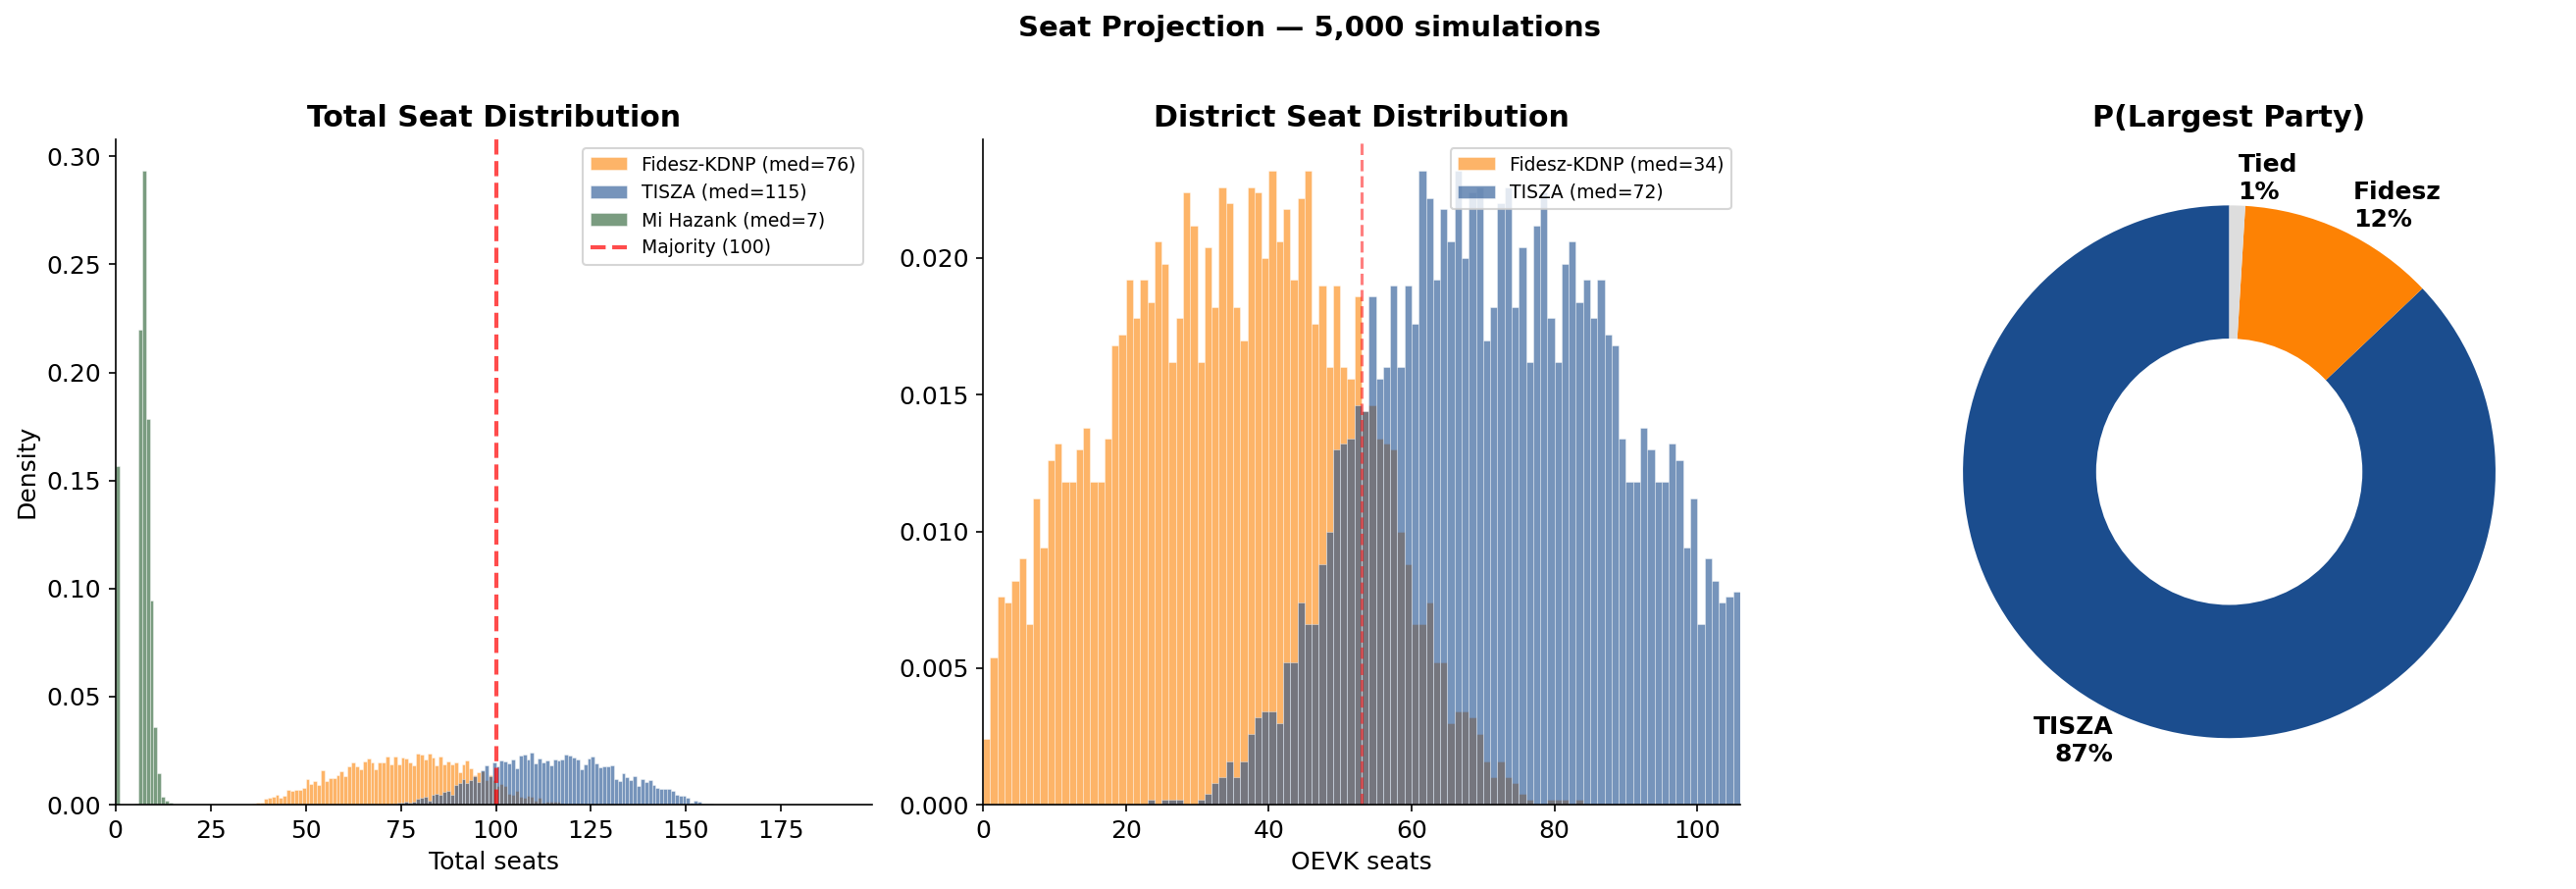

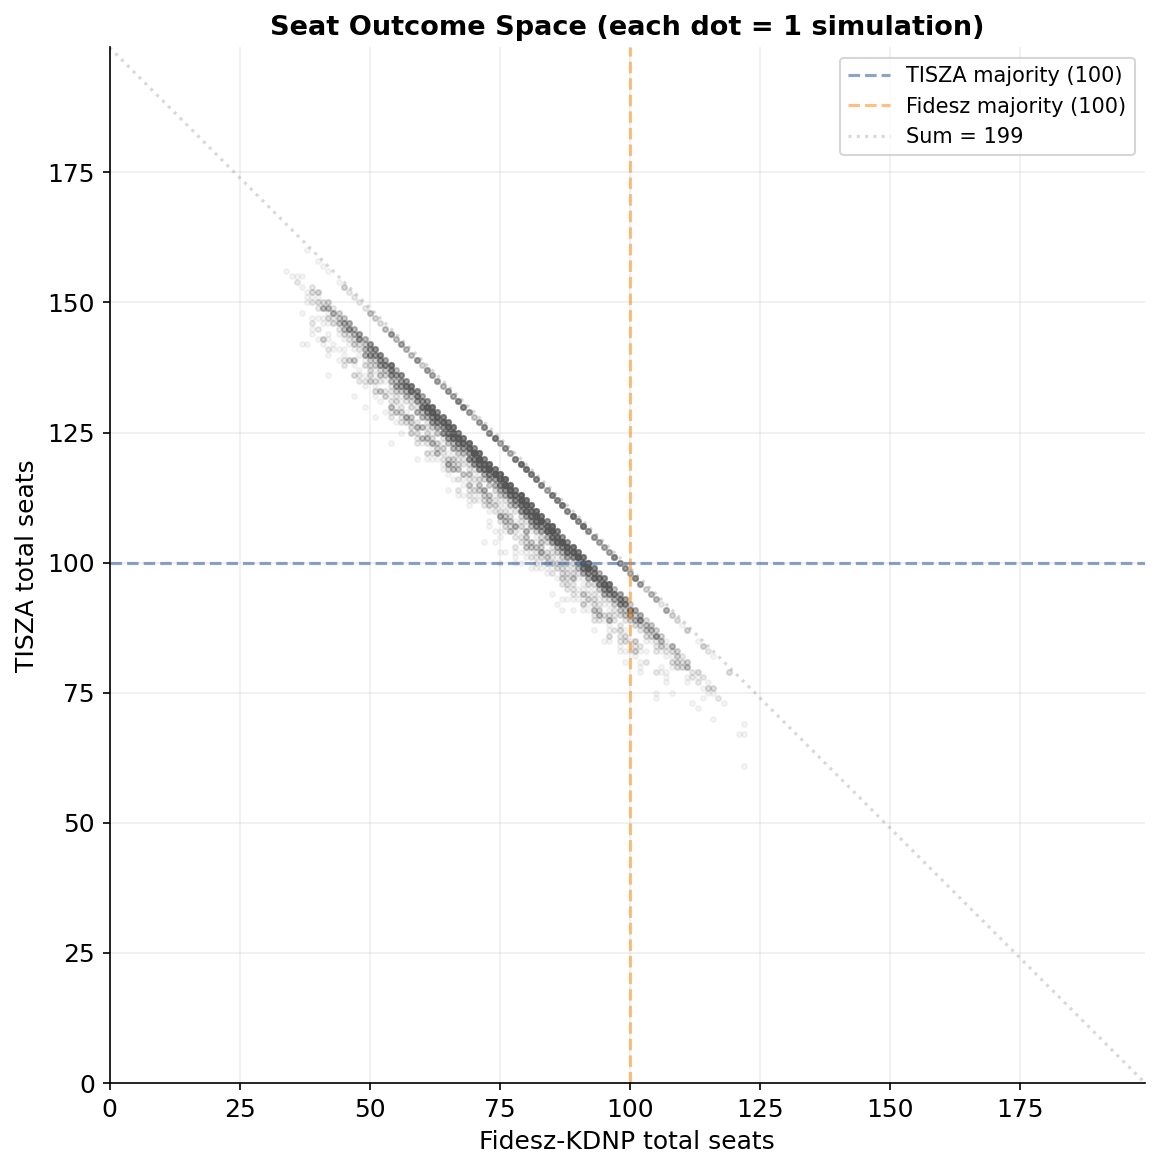

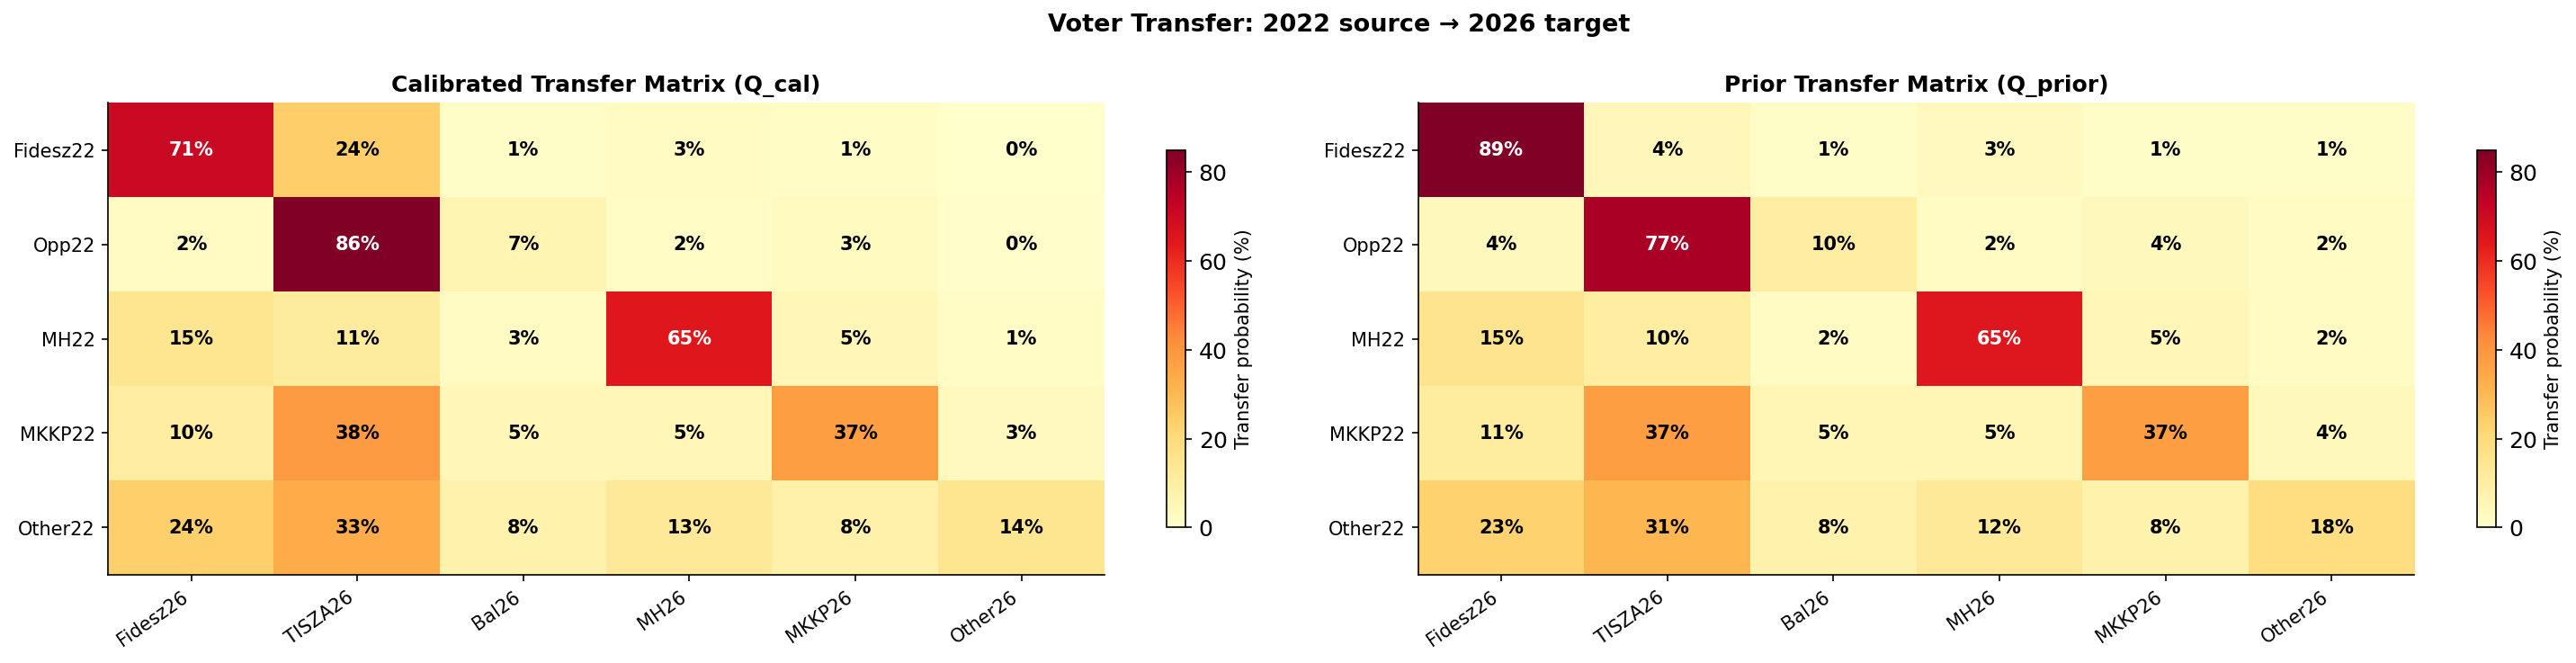

In [6]:
for plot_fn, kwargs in [
    (plot_seat_distributions, {"agg": agg}),
    (plot_seat_scatter,       {"agg": agg}),
    (plot_transfer_matrix,    {"Q": Q_cal, "Q_prior": Q_PRIOR}),
]:
    path = plot_fn(**kwargs)
    display(Image(filename=path))

## 6. 2022 replay backtest (no transfers)

Backtest the district noise model by adding logistic-normal perturbations
directly to the actual 2022 district-level vote counts (bypassing the
transfer matrix entirely). Each draw perturbs per-district vote shares
in log-space with `sigma_district`, resamples integer counts via
multinomial, then feeds into `seat_calculator` with the real 2022
party names and thresholds.

Sanity check: the actual 2022 seat outcome (Fidesz 135, Opposition 56)
should fall within the simulated distribution.

In [7]:
def replay_2022(baseline, sigma, n_sim, seed):
    """Replay 2022 with logistic-normal district noise, no transfer matrix."""
    _rng = np.random.default_rng(seed)
    oevk = baseline["oevk_votes"]
    dists = sorted(oevk.keys())
    results = []
    for _ in range(n_sim):
        noisy_oevk = {}
        for dist in dists:
            parties = list(oevk[dist].keys())
            votes = np.array([oevk[dist][p] for p in parties], dtype=float)
            total = int(votes.sum())
            log_shares = np.log(votes / votes.sum() + 1e-10)
            log_shares += _rng.normal(0, sigma, size=len(parties))
            noisy_shares = softmax(log_shares)
            noisy_votes = _rng.multinomial(total, noisy_shares)
            noisy_oevk[dist] = {p: int(v) for p, v in zip(parties, noisy_votes)}
        result = seat_calculator(
            oevk_votes=noisy_oevk,
            direct_list_votes=baseline["direct_list_votes"],
            list_meta=baseline["list_meta"],
        )
        results.append(result)
    return results


N_SIM_REPLAY = 2000
replay_results = replay_2022(baseline, sigma=cfg.sigma_district, n_sim=N_SIM_REPLAY, seed=2022)

replay_fidesz = np.array([r["total_seats"].get(FIDESZ, 0) for r in replay_results])
replay_opp = np.array([r["total_seats"].get(EEGY, 0) for r in replay_results])

print("=" * 60)
print("  2022 REPLAY (direct noise, no transfer matrix)")
print("=" * 60)
print(f"  Fidesz median seats:   {np.median(replay_fidesz):>6.0f}  (actual 2022: 135)")
print(f"  Fidesz 5th\u201395th:       {np.percentile(replay_fidesz, 5):>3.0f} \u2013 {np.percentile(replay_fidesz, 95):>3.0f}")
print(f"  Opp median seats:      {np.median(replay_opp):>6.0f}  (actual 2022:  56)")
print(f"  Opp 5th\u201395th:          {np.percentile(replay_opp, 5):>3.0f} \u2013 {np.percentile(replay_opp, 95):>3.0f}")
print(f"  P(Fidesz largest):     {(replay_fidesz > replay_opp).mean()*100:>6.1f}%")
print(f"  P(Fidesz majority):    {(replay_fidesz >= 100).mean()*100:>6.1f}%")
print(f"  P(Fidesz supermaj):    {(replay_fidesz >= 133).mean()*100:>6.1f}%")
print("=" * 60)

  2022 REPLAY (direct noise, no transfer matrix)
  Fidesz median seats:      133  (actual 2022: 135)
  Fidesz 5th–95th:       129 – 137
  Opp median seats:          59  (actual 2022:  56)
  Opp 5th–95th:           56 –  63
  P(Fidesz largest):      100.0%
  P(Fidesz majority):     100.0%
  P(Fidesz supermaj):      56.6%


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, label, actual, color in [
    (axes[0], replay_fidesz, "Fidesz-KDNP", 135, "#fd8d3c"),
    (axes[1], replay_opp, "Egys\u00e9gben (Opp)", 56, "#6baed6"),
]:
    ax.hist(data, bins=range(int(data.min()) - 1, int(data.max()) + 3),
            density=True, alpha=0.7, color=color, edgecolor="white", linewidth=0.5)
    ax.axvline(actual, color="red", linewidth=2, linestyle="--", label=f"Actual 2022: {actual}")
    ax.axvline(np.median(data), color="black", linewidth=1.5, linestyle=":", label=f"Median: {np.median(data):.0f}")
    ax.set_xlabel("Total seats", fontsize=12)
    ax.set_ylabel("Density", fontsize=12)
    ax.set_title(f"{label} \u2014 2022 replay ({N_SIM_REPLAY} sims, \u03c3={cfg.sigma_district})",
                 fontweight="bold", fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

C:\Users\takat\AppData\Local\Temp\ipykernel_31652\1139496210.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
